In [1]:
#copied from preprocessing.py, used to load preproccessed dataset to explore
#MODIFIED TO WORK WITH FILE PATHS
# for data storage
import pandas as pd

def load_datasets():
    
    # dictionary, key=file name value=its dataframe
    datasets = {}

    #7 files
    datasets["assessments"] = pd.read_csv("../data/raw/assessments.csv")
    datasets["courses"] = pd.read_csv("../data/raw/courses.csv")
    datasets["student_assessment"] = pd.read_csv("../data/raw/studentAssessment.csv")
    datasets["student_info"] = pd.read_csv("../data/raw/studentInfo.csv")
    datasets["student_registration"] = pd.read_csv("../data/raw/studentRegistration.csv")
    datasets["student_vle"] = pd.read_csv("../data/raw/studentVle.csv")
    datasets["vle"] = pd.read_csv("../data/raw/vle.csv")

    return datasets

def merge_datasets(datasets):
    # COMMON DATASET IN ALL: courses because it is central to each student/assessment/vle resource

    # first merged is student info (demographic) / registration / course info
    # merge key are shared between all, left join used to maintain all student records, will deal with missing later
    student_data = datasets["student_info"].merge(datasets["student_registration"], on=["id_student","code_module","code_presentation"], how="left")

    student_data = student_data.merge(datasets["courses"], on=["code_module","code_presentation"], how="left")

    # second merged is student specific assessment data + general assessment info + standard course
    assessment_data = datasets["student_assessment"].merge(datasets["assessments"], on="id_assessment", how="left")
    assessment_data = assessment_data.merge(datasets["courses"], on=["code_module","code_presentation"], how="left")


    # third merged is student specific VLE data + general VLE info + standard course
    vle_data = datasets["student_vle"].merge(datasets["vle"], on=["id_site","code_module","code_presentation"],how="left")
    vle_data = vle_data.merge(datasets["courses"], on=["code_module","code_presentation"], how="left")

    #final dataset is simply the vle resources, needed for final recommendations
    resource_data = datasets["vle"].copy()

    # wayy more organized, reduced 7 DFs to 4
    merged_data = {"student_data": student_data, "assessment_data":assessment_data,"vle_data":vle_data, "resource_data": resource_data}

    return merged_data

def clean_datasets(datasets):

    # not directly editing variable, makign copy of dictionary via loop (good practice)
    cleaned_datasets = {key:dataframe.copy() for key,dataframe in datasets.items()}

    # 1. handling duplicate values
    cleaned_datasets["student_data"] = cleaned_datasets["student_data"].drop_duplicates()
    cleaned_datasets["assessment_data"] = cleaned_datasets["assessment_data"].drop_duplicates()

    # will not drop duplicates in vle as it indicates multiple interactions of student with resources, will be aggregated

    # 2. handling missing values

    #starting with student data dataframe:
    #  for imd band, will fill with mode because it is categorical data and it does not introduce bias
    cleaned_datasets["student_data"]["imd_band"] = cleaned_datasets["student_data"]["imd_band"].fillna(cleaned_datasets["student_data"]["imd_band"].mode()[0])

    # for date registration, will drop because its only 45 records
    cleaned_datasets["student_data"] = cleaned_datasets["student_data"].dropna(subset=['date_registration'])

    # from research paper on dataset, date unregistration:
    # Students, who completed the course have this field empty. 
    # Students who unregistered have Withdrawn as the value of the final_result in the studentInfo table.
    # solution: create separate column with withdrawn boolean flag and fill date unregistration with the module length
    cleaned_datasets["student_data"]["withdrew"] = cleaned_datasets["student_data"]["final_result"] == "Withdrawn"
    cleaned_datasets["student_data"]["date_unregistration"] = cleaned_datasets["student_data"]["date_unregistration"].fillna(cleaned_datasets["student_data"]["module_presentation_length"])


    # next the assessment data dataframe:

    # score will be dropped, very few records and risky to introduce bias in important feature
    cleaned_datasets["assessment_data"] = cleaned_datasets["assessment_data"].dropna(subset=['score'])

    #for missing dates, according to paper:
    #If the information about the final exam cut-off day is missing, it takes place during the last week of the module-presentation.
    cleaned_datasets["assessment_data"]["date"] = cleaned_datasets["assessment_data"]["date"].fillna(cleaned_datasets["assessment_data"]["module_presentation_length"]-7)

    #dataframe for vle:
    # large nubmer of week from/to missing, will remove columns entirely as they are not critical to recommendation
    cleaned_datasets["vle_data"] = cleaned_datasets["vle_data"].drop(columns=['week_from','week_to'])

    #last dataset for missing resources

    # large nubmer of week from/to missing, will remove columns entirely as they are not critical to recommendation
    cleaned_datasets["resource_data"] = cleaned_datasets["resource_data"].drop(columns=['week_from','week_to'])

    return cleaned_datasets


def typecasting_datasets(datasets):

    # not directly editing variable, makign copy of dictionary via loop (good practice)
    typecast_datasets = {key:dataframe.copy() for key,dataframe in datasets.items()}

    #first is student data

    # convert categories columns:
    student_categorical_columns = ["code_module","code_presentation","gender","region","highest_education","imd_band","age_band","final_result"]

    for column in student_categorical_columns:
        typecast_datasets["student_data"][column] = typecast_datasets["student_data"][column].astype("category")

    #convert booleans:
    typecast_datasets["student_data"]["withdrew"] = typecast_datasets["student_data"]["withdrew"].astype(bool)

    #code inspiration from :https://stackoverflow.com/questions/43897296/pandas-converting-yes-no-to-true-false-failing
    # replace y/n with true/false before typecast
    typecast_datasets["student_data"] =typecast_datasets["student_data"].replace({'disability': {'Y': True, 'N': False}})
    #end inspired code

    typecast_datasets["student_data"]["disability"] = typecast_datasets["student_data"]["disability"].astype(bool)

    #second is assessment data

    # convert categories columns:
    assessment_categorical_columns = ["code_module","code_presentation","assessment_type"]

    for column in assessment_categorical_columns:
        typecast_datasets["assessment_data"][column] = typecast_datasets["assessment_data"][column].astype("category")

    #convert boolean
    typecast_datasets["assessment_data"]["is_banked"] = typecast_datasets["assessment_data"]["is_banked"].astype(bool)

    # vle data to typecast

    # convert categories columns:
    vle_categorical_columns = ["code_module","code_presentation","activity_type"]

    for column in vle_categorical_columns:
        typecast_datasets["vle_data"][column] = typecast_datasets["vle_data"][column].astype("category")

    #final resources data types
    # convert categories columns:
    resource_categorical_columns = ["code_module","code_presentation","activity_type"]

    for column in resource_categorical_columns:
        typecast_datasets["resource_data"][column] = typecast_datasets["resource_data"][column].astype("category")

    return typecast_datasets

def processing_datasets(datasets):

    # not directly editing variable, makign copy of dictionary via loop (good practice)
    processed_datasets = {key:dataframe.copy() for key,dataframe in datasets.items()}

    #first for student data 

    #obtain registration duration
    processed_datasets["student_data"]["registration_duration"] = processed_datasets["student_data"]["date_unregistration"] - processed_datasets["student_data"]["date_registration"]

    #next for assessment data

    #average score of student for course across all assessments
    average_scores = processed_datasets["assessment_data"].groupby(["id_student", "code_module","code_presentation"])["score"].mean()

    #will rename index so that its clear when merged with final df
    average_scores = average_scores.reset_index(name="average_score")
    
    #merge with final
    processed_datasets["assessment_data"] = processed_datasets["assessment_data"].merge(average_scores, on=["id_student", "code_module","code_presentation"],how="left")

    #resource text used for final resource data for content based filtering
    processed_datasets["resource_data"]["resource_text"] = processed_datasets["resource_data"]["code_module"].astype(str) + " " + processed_datasets["resource_data"]["code_presentation"].astype(str) + " " + processed_datasets["resource_data"]["activity_type"].astype(str)

    #no feature creation / further processing required for vle data

    #code inspired by: https://www.kaggle.com/code/veenajoe/veena-vit-project-msc-ds-june-2026#4.2-Aggregating-students-based-on-id

    #final feature creation for vle data, will create new dataframe for aggregate interactions based on it

    #grouped so each row has one student and their intercation with 1 module resource, each aggregation column specifies 
    # new columnName =  (column from VLE data used in aggregation, aggregation function)
    #main feature used for collaboartive filtering is the total resource clicks
    interaction_data = processed_datasets["vle_data"].groupby(["id_student","code_module","code_presentation","id_site","activity_type"]).agg(total_resource_clicks=("sum_click","sum"),first_used=("date","min"),last_used=("date","max")).reset_index()
    #end inspired code

    #total dfs used will be 5
    processed_datasets["interaction_data"] = interaction_data

    return processed_datasets



In [2]:
loaded_datasets = load_datasets()
merged_datasets = merge_datasets(loaded_datasets)
cleaned_datasets = clean_datasets(merged_datasets)
typecast_datasets = typecasting_datasets(cleaned_datasets)

processed_datasets = processing_datasets(typecast_datasets)

In [3]:
#for graphs / numerical calculations
import matplotlib.pyplot as plt
import numpy as np

In [4]:
#view columns to visualize, first is student data to explore
processed_datasets["student_data"].sample(5)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,withdrew,registration_duration
9845,CCC,2014B,607061,M,Scotland,A Level or Equivalent,20-30%,0-35,0,90,False,Distinction,-40.0,241.0,241,False,281.0
5412,BBB,2014B,596533,F,Yorkshire Region,A Level or Equivalent,20-30%,0-35,0,180,False,Pass,-88.0,234.0,234,False,322.0
13798,DDD,2013B,535424,M,Ireland,A Level or Equivalent,0-10%,0-35,0,60,False,Fail,-36.0,240.0,240,False,276.0
22162,EEE,2014J,695122,M,East Anglian Region,A Level or Equivalent,20-30%,0-35,0,90,False,Distinction,-21.0,269.0,269,False,290.0
24702,FFF,2013J,560592,M,Scotland,A Level or Equivalent,20-30%,0-35,0,60,False,Fail,-30.0,268.0,268,False,298.0


In [5]:
#NOTE: (will be saved with file path which will be modified in final .py file), closing figures to reduce memory usage
#gender distribution, seems to be more males than females
processed_datasets["student_data"]["gender"].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Gender Distribution for Students')
plt.tight_layout()
plt.close()

In [6]:
#next is code modules, seems to be 6 modules with BBB being most popular
processed_datasets["student_data"]["code_module"].value_counts().plot(kind='bar', color='orange')
plt.title('Code Module Distribution for Students')
plt.xlabel('code_module')
plt.ylabel('count')
plt.tight_layout()
plt.close()

In [7]:
#region distribution, seems focused on Europe/UK
processed_datasets["student_data"]["region"].value_counts().plot(kind='bar',color='green')
plt.title('Region Distribution for Students')
plt.xlabel('region')
plt.ylabel('count')
plt.tight_layout()
plt.close()

In [8]:
#final results distribution, seems to be mostly pass or withdrawn
processed_datasets["student_data"]["final_result"].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Final Result Distribution for Students')
plt.tight_layout()
plt.close()

In [9]:
#registration duration, seems to be a lot of outliers but concentrated around 200-300 days
processed_datasets["student_data"].boxplot(column="registration_duration", color='blue')
plt.title('Registration Duration Box Plot for Students')
plt.ylabel('days')
plt.tight_layout()
plt.close()

In [10]:
#disability distribution, seems to be mostly no disabled students
processed_datasets["student_data"]["disability"].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Disability Distribution for Students')
plt.tight_layout()
plt.close()

In [11]:
#NEXT is assessment data to explore, view sample of columns to visualize
processed_datasets["assessment_data"].sample(5)

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,module_presentation_length,average_score
164960,37425,634316,54,False,70.0,GGG,2014B,TMA,61.0,0.0,241,82.111111
154927,34908,569080,205,False,84.0,FFF,2014J,CMA,241.0,0.0,269,86.666667
148217,34902,150282,143,False,82.0,FFF,2014J,TMA,136.0,25.0,269,77.666667
80338,25351,465441,122,False,94.0,DDD,2013J,TMA,123.0,20.0,261,80.500000
11065,14992,503878,95,False,100.0,BBB,2013B,CMA,89.0,1.0,240,84.750000


In [12]:
#assessment type distribution, seems to be mostly tutor marked assessments
processed_datasets["assessment_data"]["assessment_type"].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Type Distribution for Asssessments')
plt.tight_layout()
plt.close()

In [13]:
#single student has many assesements, so must group by student id for next visualizations
processed_datasets["assessment_data"].loc[processed_datasets["assessment_data"]["id_student"] == 421455]

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,module_presentation_length,average_score
1938,1758,421455,22,False,75.0,AAA,2014J,TMA,19.0,10.0,269,77.8
2145,1759,421455,53,False,90.0,AAA,2014J,TMA,54.0,20.0,269,77.8
2547,1760,421455,116,False,74.0,AAA,2014J,TMA,117.0,20.0,269,77.8
2844,1761,421455,165,False,81.0,AAA,2014J,TMA,166.0,20.0,269,77.8
3029,1762,421455,213,False,69.0,AAA,2014J,TMA,215.0,30.0,269,77.8


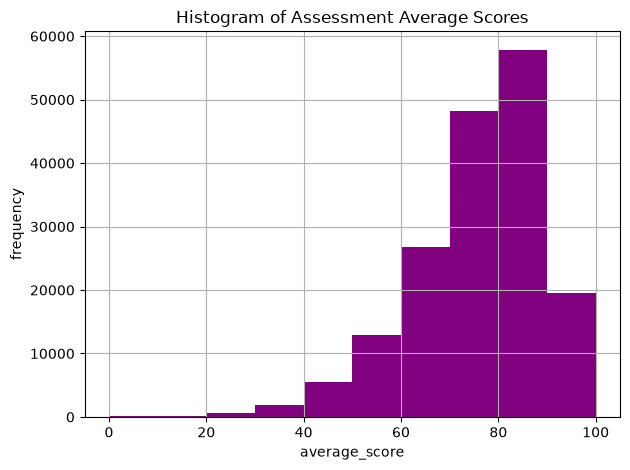

In [14]:
#histogram of average assessment score, seems to be mostly 70%+ (good marks)
processed_datasets["assessment_data"]["average_score"].hist(color='purple')
plt.title('Histogram of Assessment Average Scores')
plt.xlabel("average_score")
plt.ylabel("frequency")
plt.tight_layout()

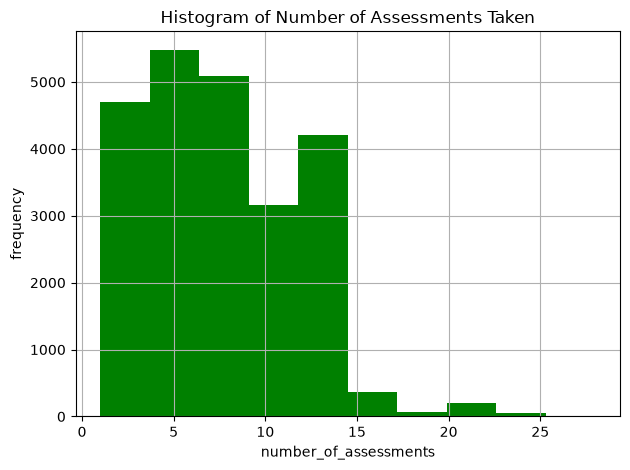

In [15]:
#histogram of number of assessments per student, seems to be mostly between 5-10
assessments_summary = processed_datasets["assessment_data"].groupby('id_student')['id_assessment'].count()

assessments_summary.hist(color='green')
plt.title('Histogram of Number of Assessments Taken')
plt.xlabel("number_of_assessments")
plt.ylabel("frequency")
plt.tight_layout()

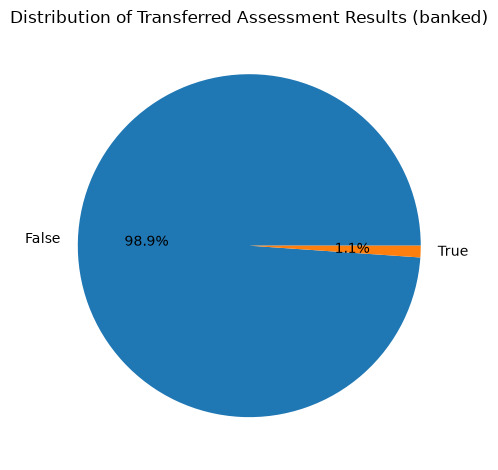

In [16]:
#is banked assessment distribution, seems to be almost all no transfer (organized university result release process)
processed_datasets["assessment_data"]["is_banked"].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Distribution of Transferred Assessment Results (banked)')
plt.tight_layout()

In [17]:
#NEXT EXPLORATION for vle data, sample to view columns
processed_datasets["vle_data"].sample(5)

,code_module,code_presentation,id_student,id_site,date,sum_click,activity_type,module_presentation_length
8378217,FFF,2014B,630015,779718,-17,1,url,241
3134963,DDD,2013B,439542,547836,-14,1,url,240
9655138,FFF,2014J,696318,882545,91,3,forumng,269
2652359,CCC,2014J,630013,909260,43,2,resource,269
4994379,DDD,2014J,569737,813701,73,2,homepage,262


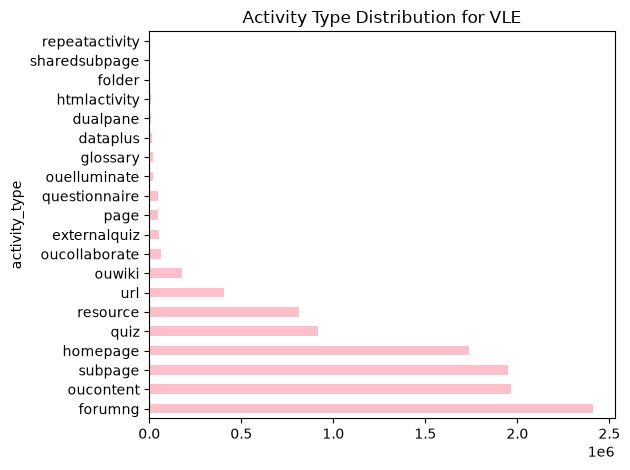

In [18]:
#activity type dsitribution, seems to be mostly forumng / oucontent
processed_datasets["vle_data"]["activity_type"].value_counts().plot(kind='barh',color='pink')
plt.title('Activity Type Distribution for VLE')
plt.tight_layout()

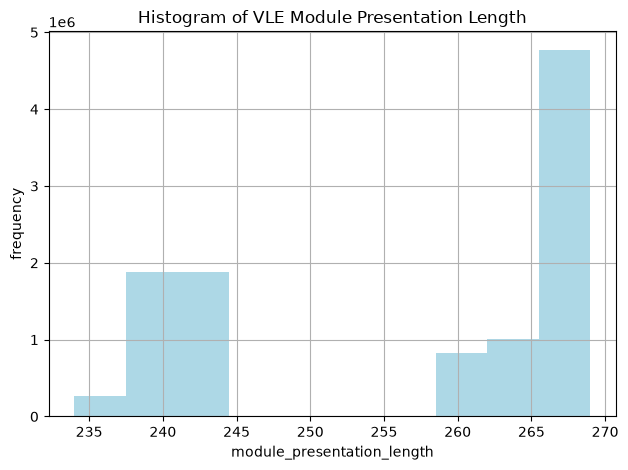

In [19]:
#module presentation length histogram, seems to be most modules around 265-270 days
processed_datasets["vle_data"]["module_presentation_length"].hist(color='lightblue')
plt.title('Histogram of VLE Module Presentation Length')
plt.xlabel("module_presentation_length")
plt.ylabel("frequency")
plt.tight_layout()

In [20]:
#NEXT is resource data
processed_datasets["resource_data"].sample(5)

,id_site,code_module,code_presentation,activity_type,resource_text
3603,1004387,DDD,2014J,oucontent,DDD 2014J oucontent
3102,773308,DDD,2014B,resource,DDD 2014B resource
1635,730031,CCC,2014B,subpage,CCC 2014B subpage
2027,547668,DDD,2013B,resource,DDD 2013B resource
6335,897052,GGG,2014J,resource,GGG 2014J resource


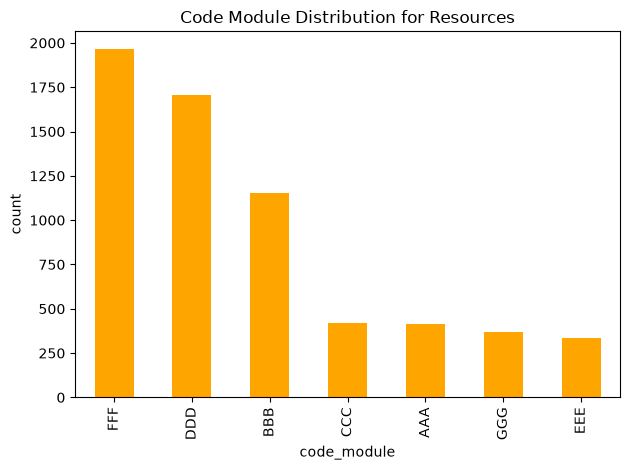

In [21]:
#code modules, seems to be 6 modules with FFF having the most resources
processed_datasets["resource_data"]["code_module"].value_counts().plot(kind='bar', color='orange')
plt.title('Code Module Distribution for Resources')
plt.xlabel('code_module')
plt.ylabel('count')
plt.tight_layout()

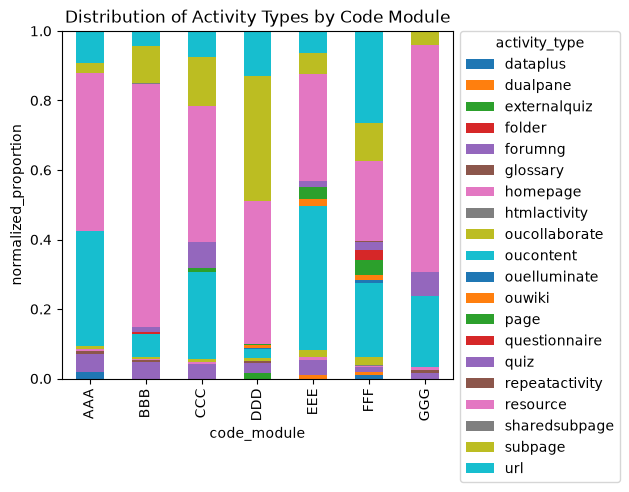

In [22]:
#cross tabulation of code module against activity type to create stacked bar chart
vle_crosstab = pd.crosstab(processed_datasets["resource_data"]["code_module"], processed_datasets["resource_data"]["activity_type"], normalize="index")

#seems to be mostly all have high proportion of hompepage and oucontent activities
vle_crosstab.plot(kind="bar",stacked=True)

plt.title("Distribution of Activity Types by Code Module")
plt.xlabel("code_module")
plt.ylabel("normalized_proportion")
plt.legend(title="activity_type", bbox_to_anchor=(1, 1.02), loc='upper left')
plt.tight_layout()

In [23]:
#last is interaction data, see sample
processed_datasets["interaction_data"].sample(5)

,id_student,code_module,code_presentation,id_site,activity_type,total_resource_clicks,first_used,last_used
275849,383445,FFF,2014J,883076,subpage,1,145,145
254897,367898,FFF,2014B,779736,url,1,88,88
69450,141648,FFF,2013J,716437,quiz,6,65,65
1147486,604398,DDD,2013J,674084,subpage,3,5,25
1295074,624209,CCC,2014J,909305,resource,7,97,100


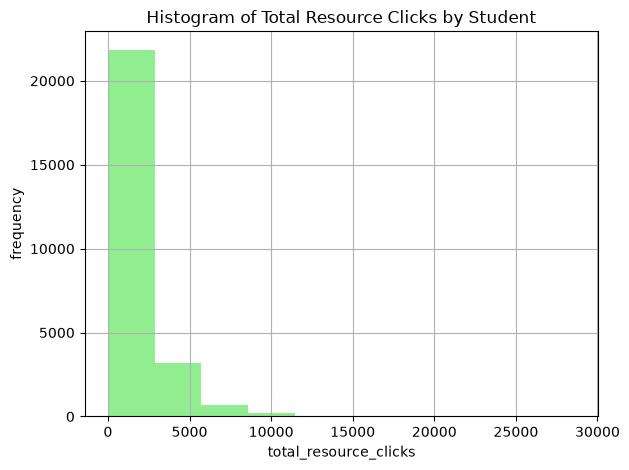

In [24]:
#plots total clicks per student, seems to be most students have low clicks 0-5000
processed_datasets["interaction_data"].groupby("id_student")["total_resource_clicks"].sum().hist(color='lightgreen')
plt.title("Histogram of Total Resource Clicks by Student")
plt.xlabel("total_resource_clicks")
plt.ylabel("frequency")
plt.tight_layout()

In [25]:
#added to preprocessing function
#also derive feature of duration of clicks from aggregated data
processed_datasets["interaction_data"]["click_duration"] = processed_datasets["interaction_data"]["last_used"] - processed_datasets["interaction_data"]["first_used"]

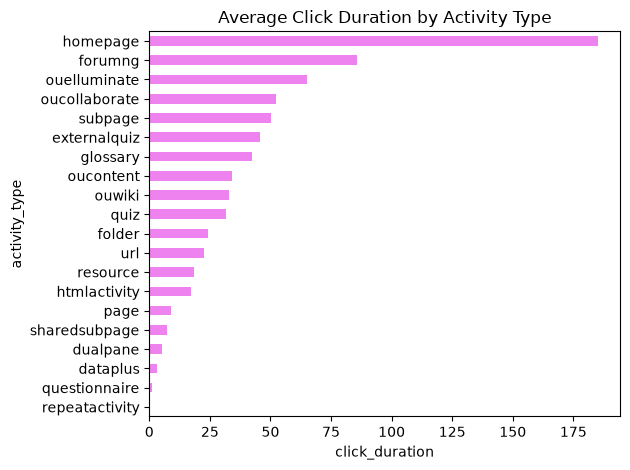

In [30]:
#plot horizontal bar graph for average click duration per activity type, seems to be significantly higher engagement for homepage 
processed_datasets["interaction_data"].groupby("activity_type")["click_duration"].mean().sort_values().plot(kind='barh',color='violet')
plt.title("Average Click Duration by Activity Type")
plt.xlabel("click_duration")
plt.ylabel("activity_type")
plt.tight_layout()